In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import TextVectorization, Input, Dense, Embedding
from tensorflow.keras.layers import GlobalMaxPooling1D, Conv1D, MaxPooling1D
from tensorflow.keras.models import Model
from sklearn.metrics import f1_score

2026-02-01 20:03:45.308574: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-01 20:03:45.341695: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-01 20:03:46.405484: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
df = pd.read_csv('spam.csv',encoding='ISO-8859-1')

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
!head spam.csv

v1,v2,,,
ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",,,
ham,Ok lar... Joking wif u oni...,,,
spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,,,
ham,U dun say so early hor... U c already then say...,,,
ham,"Nah I don't think he goes to usf, he lives around here though",,,
spam,"FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, �1.50 to rcv",,,
ham,Even my brother is not like to speak with me. They treat me like aids patent.,,,
ham,As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Callers. Press *9 to copy your friends Callertune,,,
spam,WINNER!! As a valued network customer you have been selected to receivea �900 prize reward! To claim call 09061701461. Claim 

In [5]:
df = df.drop(["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], axis=1)

In [6]:
# rename columns to something better
df.columns = ['labels', 'data']

In [7]:
df.head()

,labels,data
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
# create binary labels
df['b_labels'] = df['labels'].map({'ham': 0, 'spam': 1})
Y = df['b_labels'].values

In [9]:
# split up the data
df_train, df_test, Ytrain, Ytest = train_test_split(
    df['data'], Y, test_size=0.33)

In [10]:
# create tf datasets
train_ds = tf.data.Dataset.from_tensor_slices((df_train.values, Ytrain))
test_ds = tf.data.Dataset.from_tensor_slices((df_test.values, Ytest))

I0000 00:00:1769958227.922333 3172605 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3957 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


In [11]:
# Convert sentences to sequences
MAX_VOCAB_SIZE = 20000
vectorization = TextVectorization(max_tokens=MAX_VOCAB_SIZE)
vectorization.adapt(train_ds.map(lambda x, y: x))

2026-02-01 20:04:03.995837: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [12]:
# Shuffle and batch the dataset
train_ds = train_ds.shuffle(
    buffer_size=10000).batch(32).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(32).prefetch(tf.data.AUTOTUNE)

In [13]:
V = len(vectorization.get_vocabulary())

In [14]:
# This is annoying, but we have to find the max sequence length first
# and pad ALL sequences to this length
# Otherwise, with some inputs, the resulting array will be too short in the time
# dimension, leading to a series of convolutions shrinking the input length to 0
T = 0
for x, y in train_ds:
  t = vectorization(x).shape[1]
  if t > T:
    T = t
print(T)

171


2026-02-01 20:04:05.071708: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [15]:
vectorization2 = TextVectorization(
    max_tokens=MAX_VOCAB_SIZE,
    output_sequence_length=T,
    vocabulary=vectorization.get_vocabulary(),  # no need to adapt()
)

In [16]:
# Create the model

# We get to choose embedding dimensionality
D = 20

# Note: we actually want to the size of the embedding to (V + 1) x D,
# because the first index starts from 1 and not 0.
# Thus, if the final index of the embedding matrix is V,
# then it actually must have size V + 1.

# if string not specified, will get string -> float casting error
i = Input(shape=(1,), dtype=tf.string)
x = vectorization2(i)
x = Embedding(V, D)(x)
x = Conv1D(32, 3, activation='relu')(x)
x = MaxPooling1D(3)(x)
x = Conv1D(64, 3, activation='relu')(x)
x = MaxPooling1D(3)(x)
x = Conv1D(128, 3, activation='relu')(x)
x = GlobalMaxPooling1D()(x)
x = Dense(1, activation='sigmoid')(x)

model = Model(i, x)

In [17]:
# Compile and fit
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


print('Training model...')
r = model.fit(
    train_ds,
    epochs=5,
    validation_data=test_ds
)

Training model...
Epoch 1/5


2026-02-01 20:04:06.787967: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91801


117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8653 - loss: 0.3662 - val_accuracy: 0.8891 - val_loss: 0.2106
Epoch 2/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9676 - loss: 0.1022 - val_accuracy: 0.9793 - val_loss: 0.0708
Epoch 3/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9925 - loss: 0.0261 - val_accuracy: 0.9804 - val_loss: 0.0611
Epoch 4/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9979 - loss: 0.0076 - val_accuracy: 0.9799 - val_loss: 0.0619
Epoch 5/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9992 - loss: 0.0030 - val_accuracy: 0.9804 - val_loss: 0.0698


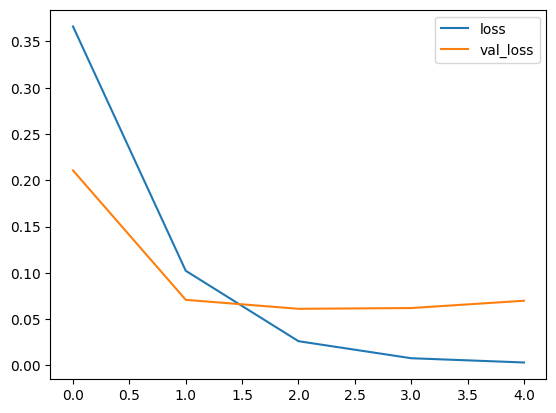

In [18]:
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

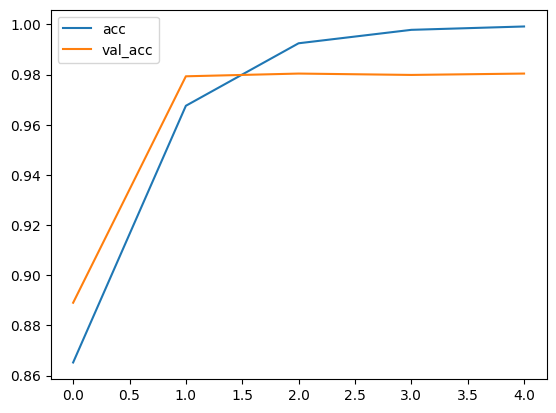

In [19]:
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

In [20]:
pred_ds = tf.data.Dataset.from_tensor_slices(df_train.values)\
    .batch(32)

y_pred = model.predict(pred_ds)
y_pred = (y_pred.flatten() > 0.5).astype(int)

f1 = f1_score(Ytrain, y_pred)
print("Train F1:", f1)

117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Train F1: 0.9979674796747967


In [21]:
pred_ds_test = tf.data.Dataset.from_tensor_slices(df_test.values)\
    .batch(32)

y_pred_test = model.predict(pred_ds_test)
y_pred_test = (y_pred_test.flatten() > 0.5).astype(int)

f1 = f1_score(Ytest, y_pred_test)
print("Test F1:", f1)

58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Test F1: 0.9305019305019305
